<h2> Visualizations </h2>

In [1]:
import math
import json
import pandas as pd
import numpy as np
import ast
from matplotlib import pyplot as plt
import scipy.stats
import seaborn as sns

In [2]:
def read_scores(file):
    scores = []
    for line in file:
        if line[0] == "{":
            scores.append(json.loads(json.dumps(ast.literal_eval(line.strip()))))
    return scores

In [3]:
def create_CER_dataset(scores):
    epochs = []
    valid_loss = []
    valid_CharacTER = []
    
    for score in scores:
        epochs.append(score["epoch"])
        valid_loss.append(score["valid_loss"])
        valid_CharacTER.append(score["valid_CharacTER"])
        
    return pd.DataFrame({'epoch': epochs, 'valid_loss': valid_loss, 'valid_CharacTER': valid_CharacTER})
    

<h3>Training 2: Transcriptions and Augmentations</h3>

In [4]:
file = open("results/tr_02_ignore.txt", "r")

scores = read_scores(file)
dataset_ignore = create_CER_dataset(scores)

dataset_ignore.head()

,epoch,valid_loss,valid_CharacTER
0,1,0.392927,18.860803
1,2,0.388899,18.928003
2,3,0.387800,15.618337
3,4,0.381493,14.191022
4,5,0.364223,16.250268


In [7]:
file = open("results/tr_02_substitution.txt", "r", encoding="utf8")

scores = read_scores(file)
dataset_subst = create_CER_dataset(scores)

dataset_subst.head()

,epoch,valid_loss,valid_CharacTER
0,1,0.393837,19.005347
1,2,0.390896,13.433056
2,3,0.387959,15.608150
3,4,0.375208,14.039315
4,5,0.365216,13.694803


In [8]:
file = open("results/tr_02_reduced.txt", "r")

scores = read_scores(file)
dataset_reduce = create_CER_dataset(scores)

dataset_reduce.head()

,epoch,valid_loss,valid_CharacTER
0,1,0.628489,11.846143
1,2,0.620657,10.522123
2,3,0.622914,7.758008
3,4,0.614061,10.263769
4,5,0.610089,9.876633


Best evaluation ignore strategy: Epoch 16, value 3.185915315072006
Best evaluation substitution strategy: Epoch 138, value 3.804489331387998
Best evaluation reduce strategy: Epoch 49, value 2.586785526370685


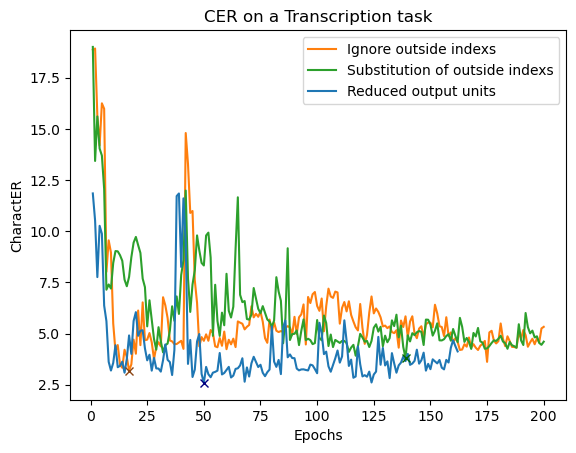

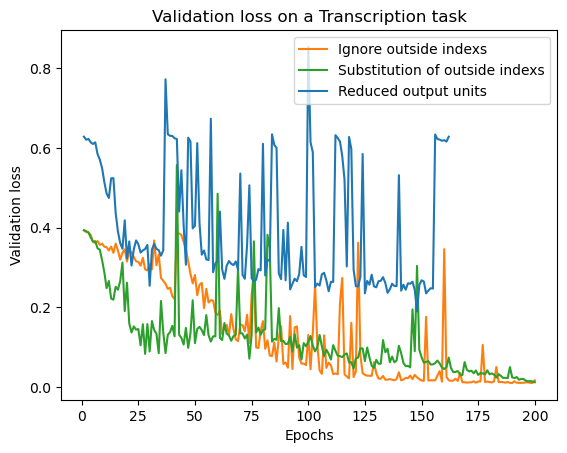

In [9]:
# Visualize training CharacTER
plt.plot(dataset_ignore["epoch"], dataset_ignore["valid_CharacTER"], label='Ignore outside indexs', color="tab:orange")
plt.plot(dataset_subst["epoch"], dataset_subst["valid_CharacTER"], label='Substitution of outside indexs', color="tab:green")
plt.plot(dataset_reduce["epoch"], dataset_reduce["valid_CharacTER"], label='Reduced output units', color="tab:blue")

minCER = np.argmin(dataset_ignore["valid_CharacTER"])
plt.plot(dataset_ignore["epoch"][minCER], dataset_ignore["valid_CharacTER"][minCER], marker='x', color="saddlebrown")
print("Best evaluation ignore strategy: Epoch " + str(minCER) + ", value " + str(dataset_ignore["valid_CharacTER"][minCER]))

minCER = np.argmin(dataset_subst["valid_CharacTER"])
plt.plot(dataset_subst["epoch"][minCER], dataset_subst["valid_CharacTER"][minCER], marker='x', color="darkgreen")
print("Best evaluation substitution strategy: Epoch " + str(minCER) + ", value " + str(dataset_subst["valid_CharacTER"][minCER]))

minCER = np.argmin(dataset_reduce["valid_CharacTER"])
plt.plot(dataset_reduce["epoch"][minCER], dataset_reduce["valid_CharacTER"][minCER], marker='x', color="navy")
print("Best evaluation reduce strategy: Epoch " + str(minCER) + ", value " + str(dataset_reduce["valid_CharacTER"][minCER]))

plt.xlabel('Epochs')
plt.ylabel('CharactER')
plt.legend()
plt.title("CER on a Transcription task")

plt.savefig('plots/tr_02_cer.png', bbox_inches='tight')
plt.show()


# Visualize training Loss
plt.plot(dataset_ignore["epoch"], dataset_ignore["valid_loss"], label='Ignore outside indexs', color="tab:orange")
plt.plot(dataset_subst["epoch"], dataset_subst["valid_loss"], label='Substitution of outside indexs', color="tab:green")
plt.plot(dataset_reduce["epoch"], dataset_reduce["valid_loss"], label='Reduced output units', color="tab:blue")

plt.xlabel('Epochs')
plt.ylabel('Validation loss')
plt.legend()
plt.title("Validation loss on a Transcription task")

plt.savefig('plots/tr_02_loss.png', bbox_inches='tight')
plt.show()

Best evaluation ignore strategy: Epoch 16, value 3.185915315072006
Best evaluation substitution strategy: Epoch 138, value 3.804489331387998
Best evaluation reduce strategy: Epoch 49, value 2.586785526370685


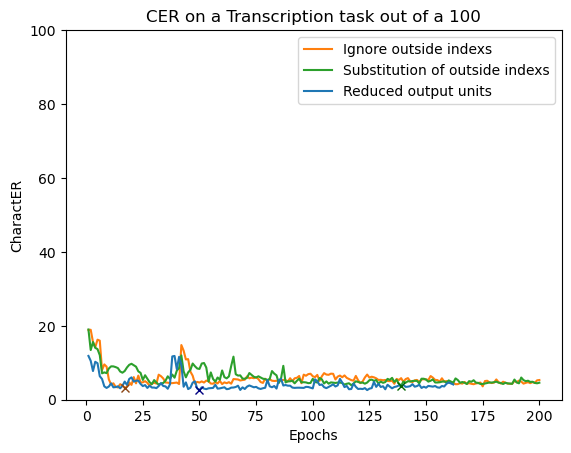

In [10]:
# Visualize training CharacTER out of 100
plt.plot(dataset_ignore["epoch"], dataset_ignore["valid_CharacTER"], label='Ignore outside indexs', color="tab:orange")
plt.plot(dataset_subst["epoch"], dataset_subst["valid_CharacTER"], label='Substitution of outside indexs', color="tab:green")
plt.plot(dataset_reduce["epoch"], dataset_reduce["valid_CharacTER"], label='Reduced output units', color="tab:blue")

minCER = np.argmin(dataset_ignore["valid_CharacTER"])
plt.plot(dataset_ignore["epoch"][minCER], dataset_ignore["valid_CharacTER"][minCER], marker='x', color="saddlebrown")
print("Best evaluation ignore strategy: Epoch " + str(minCER) + ", value " + str(dataset_ignore["valid_CharacTER"][minCER]))

minCER = np.argmin(dataset_subst["valid_CharacTER"])
plt.plot(dataset_subst["epoch"][minCER], dataset_subst["valid_CharacTER"][minCER], marker='x', color="darkgreen")
print("Best evaluation substitution strategy: Epoch " + str(minCER) + ", value " + str(dataset_subst["valid_CharacTER"][minCER]))

minCER = np.argmin(dataset_reduce["valid_CharacTER"])
plt.plot(dataset_reduce["epoch"][minCER], dataset_reduce["valid_CharacTER"][minCER], marker='x', color="navy")
print("Best evaluation reduce strategy: Epoch " + str(minCER) + ", value " + str(dataset_reduce["valid_CharacTER"][minCER]))

plt.ylim(0, 100)

plt.xlabel('Epochs')
plt.ylabel('CharactER')
plt.legend()
plt.title("CER on a Transcription task out of a 100")

plt.savefig('plots/tr_02_cer_100.png', bbox_inches='tight')
plt.show()

<br >